# Problema 2 - Mediciones de tiempo
Medimos el tiempo de ejecución de Dijkstra (implementación del anexo) y lo contrastamos con una referencia cuadrática $O(n^2)$.

In [20]:
%pip install -q matplotlib seaborn scipy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
import os
import sys
import random
import numpy as np
import scipy as sp
import seaborn as sns
from matplotlib import pyplot as plt

# Importamos módulos desde el directorio actual y su padre
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(current_dir)
sys.path.append(parent_dir)

# Importamos la función a probar
from problema_2_for_test import construir_matriz_costos_desde_ejes, ejecutar_dijkstra
from util import time_algorithm

# Establecemos semillas para la reproducibilidad de los resultados
random.seed(12345)
np.random.seed(12345)
sns.set_theme(style="whitegrid")

## Generación de datos para las mediciones y gráficos
Para cada tamaño $n$, generamos un grafo no dirigido, conexo y ponderado con costos positivos.

Para garantizar conectividad, en cada instancia se construye primero una cadena base $1-2-3-\dots-n$, y luego se agregan ejes extra aleatorios sin repetir pares de vértices.

En cada tamaño se mide el tiempo de ejecución promedio de Dijkstra desde un origen fijo (vértice 1).
Los tamaños de entrada se toman en un rango creciente de vértices para observar la tendencia empírica del algoritmo.

Finalmente, los tiempos medidos (en milisegundos) se ajustan contra una referencia teórica cuadrática $O(n^2)$ y se grafica también el error absoluto del ajuste.

In [22]:
def generar_ejes_random(n: int, extra_factor: int = 2):
    usados = set()
    ejes = []

    # Cadena base para garantizar conectividad
    for a in range(1, n):
        b = a + 1
        c = random.randint(10, 500)
        usados.add((a, b))
        ejes.append((a, b, c))

    # Evita pedir más ejes de los que puede tener un grafo simple no dirigido
    max_ejes = (n * (n - 1)) // 2
    max_extra = max_ejes - (n - 1)
    objetivo_extra = min(extra_factor * n, max_extra)
    while len(ejes) < (n - 1 + objetivo_extra):
        a = random.randint(1, n)
        b = random.randint(1, n)
        if a == b:
            continue
        if a > b:
            a, b = b, a
        if (a, b) in usados:
            continue

        c = random.randint(10, 500)
        usados.add((a, b))
        ejes.append((a, b, c))

    return ejes

def generar_instancia(n: int):
    ejes = generar_ejes_random(n)
    cost = construir_matriz_costos_desde_ejes(n, ejes)
    origen = 1
    return n, cost, origen

def args_tiempo(n: int):
    return generar_instancia(int(n))

# Rango de medición (más práctico para notebook)
x = np.linspace(20, 300, 20).astype(int)
print("rango:", x)

# util.time_algorithm devuelve segundos; convertimos a ms para mostrar
results_tiempo_s = time_algorithm(ejecutar_dijkstra, x, args_tiempo)
results_tiempo = {int(n): t * 1000.0 for n, t in results_tiempo_s.items()}

print("Resultados (ms):")
for n, t in results_tiempo.items():
    print(f"Tiempo para n={n}: {t:.12g} ms")

rango: [ 20  34  49  64  78  93 108 123 137 152 167 182 196 211 226 241 255 270
 285 300]
Resultados (ms):
Tiempo para n=20: 0.062108039856 ms
Tiempo para n=34: 0.117969512939 ms
Tiempo para n=49: 0.232100486755 ms
Tiempo para n=64: 0.350642204285 ms
Tiempo para n=78: 0.513696670532 ms
Tiempo para n=93: 0.807332992554 ms
Tiempo para n=108: 1.01401805878 ms
Tiempo para n=123: 1.3188123703 ms
Tiempo para n=137: 1.61294937134 ms
Tiempo para n=152: 2.08287239075 ms
Tiempo para n=167: 2.45530605316 ms
Tiempo para n=182: 3.31161022186 ms
Tiempo para n=196: 3.62918376923 ms
Tiempo para n=211: 4.2932510376 ms
Tiempo para n=226: 4.86795902252 ms
Tiempo para n=241: 5.61609268188 ms
Tiempo para n=255: 6.19478225708 ms
Tiempo para n=270: 6.59492015839 ms
Tiempo para n=285: 7.37943649292 ms
Tiempo para n=300: 8.57696533203 ms


c_1 = 9.41258167757e-05, c_2 = -0.0249442216929
Error cuadrático total: 0.304766745119


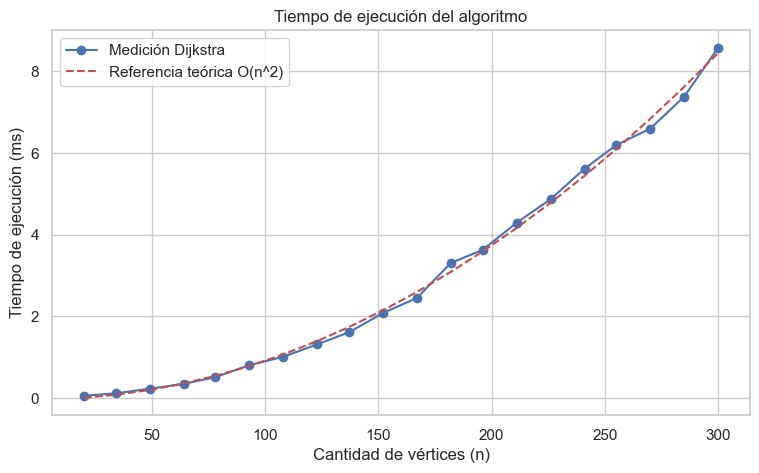

In [23]:
# scipy nos pide una función que recibe primero x y luego los parámetros a ajustar:
f_tiempo = lambda x, c1, c2: c1 * x**2 + c2
c, pcov = sp.optimize.curve_fit(f_tiempo, x, [results_tiempo[n] for n in x])
r = np.sum((c[0] * x**2 + c[1] - [results_tiempo[n] for n in x])**2)

print(f"c_1 = {c[0]:.12g}, c_2 = {c[1]:.12g}")
print(f"Error cuadrático total: {r:.12g}")

ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, [results_tiempo[n] for n in x], "o-", label="Medición Dijkstra")
ax.plot(x, [c[0] * n**2 + c[1] for n in x], "r--", label="Referencia teórica O(n^2)")
ax.set_title("Tiempo de ejecución del algoritmo")
ax.set_xlabel("Cantidad de vértices (n)")
ax.set_ylabel("Tiempo de ejecución (ms)")
ax.legend()

Text(0, 0.5, 'Error absoluto (ms)')

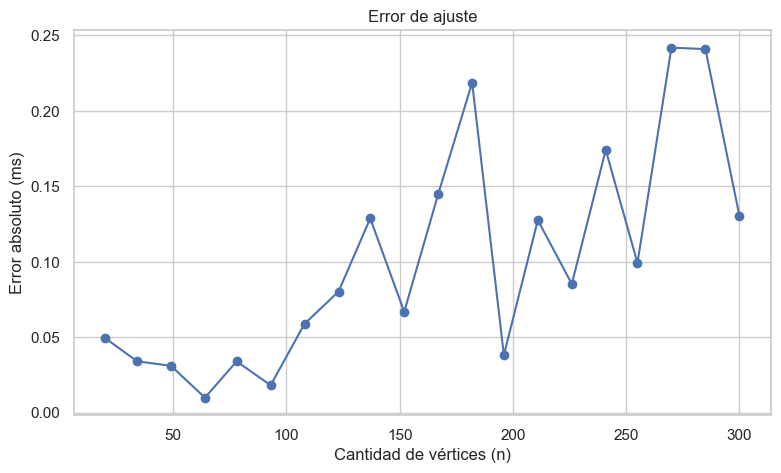

In [24]:
ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
errors = [np.abs(c[0] * n**2 + c[1] - results_tiempo[n]) for n in x]
ax.plot(x, errors, "o-")
ax.set_title("Error de ajuste")
ax.set_xlabel("Cantidad de vértices (n)")
ax.set_ylabel("Error absoluto (ms)")